### Setup and Imports

In [1]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add src to path for imports
sys.path.append('..')

from src.data_loader import DataLoader
from src.eda_utils import EDAUtils

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#### LOAD DATA

In [2]:
loader = DataLoader("../data/MachineLearningRating_v3.txt")
df = loader.load_data()
df.head()

Loading data from: ..\data\MachineLearningRating_v3.txt
Loaded: 1,000,096 rows, 52 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
1,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
2,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145247,12827,2015-01-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.256435,0.0
4,145247,12827,2015-04-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,50.474737,0.0


In [3]:
info = loader.get_data_info()
loader.print_info(info)

DATASET INFORMATION
Rows:   1,000,096
Cols:   52
Memory: 2373.96 MB

Columns:
   1. UnderwrittenCoverID
   2. PolicyID
   3. TransactionMonth
   4. IsVATRegistered
   5. Citizenship
   6. LegalType
   7. Title
   8. Language
   9. Bank
  10. AccountType
  11. MaritalStatus
  12. Gender
  13. Country
  14. Province
  15. PostalCode
  16. MainCrestaZone
  17. SubCrestaZone
  18. ItemType
  19. mmcode
  20. VehicleType
  21. RegistrationYear
  22. make
  23. Model
  24. Cylinders
  25. cubiccapacity
  26. kilowatts
  27. bodytype
  28. NumberOfDoors
  29. VehicleIntroDate
  30. CustomValueEstimate
  31. AlarmImmobiliser
  32. TrackingDevice
  33. CapitalOutstanding
  34. NewVehicle
  35. WrittenOff
  36. Rebuilt
  37. Converted
  38. CrossBorder
  39. NumberOfVehiclesInFleet
  40. SumInsured
  41. TermFrequency
  42. CalculatedPremiumPerTerm
  43. ExcessSelected
  44. CoverCategory
  45. CoverType
  46. CoverGroup
  47. Section
  48. Product
  49. StatutoryClass
  50. StatutoryRiskType
  

### Fix data types

In [4]:
df = EDAUtils.fix_dtypes(df)
print(f"Data types after fixing:\n{df.dtypes.value_counts()}")

Data types after fixing:
str               37
float64           10
datetime64[us]     2
bool               1
int64              1
Name: count, dtype: int64


In [5]:
EDAUtils.get_descriptive_stats(df)

,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,CapitalOutstanding,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1000096.00,999544.00,999544.00,999544.00,999544.00,220454.00,999774.00,1000096.00,1000096.00,1000096.00,1000096.00
mean,2010.23,4.05,2466.74,97.21,4.02,225532.09,52605.09,604173.94,117.88,61.91,64.86
std,3.26,0.29,442.80,19.39,0.47,564518.22,111417.26,1508333.10,399.70,230.28,2384.08
min,1987.00,0.00,0.00,0.00,0.00,20000.00,-2.00,0.01,0.00,-782.58,-12002.41
25%,2008.00,4.00,2237.00,75.00,4.00,135000.00,0.00,5000.00,3.22,0.00,0.00
50%,2011.00,4.00,2694.00,111.00,4.00,220000.00,0.00,7500.00,8.44,2.18,0.00
75%,2013.00,4.00,2694.00,111.00,4.00,280000.00,0.00,250000.00,90.00,21.93,0.00
max,2015.00,10.00,12880.00,309.00,6.00,26550000.00,700000.00,12636200.00,74422.17,65282.60,393092.11


Get missing values summary

In [6]:
missing_df = EDAUtils.get_missing_summary(df)
print("Missing values summary:")
print(missing_df)  

Missing values summary:
                      Count  Percentage
CrossBorder          999398   99.930207
CustomValueEstimate  779642   77.956716
Rebuilt              641899   64.183738
WrittenOff           641899   64.183738
Converted            641899   64.183738
NewVehicle           153295   15.328029
Bank                 145961   14.594699
AccountType           40232    4.022814
Gender                 9536    0.953508
MaritalStatus          8259    0.825821
mmcode                  552    0.055195
VehicleType             552    0.055195
make                    552    0.055195
NumberOfDoors           552    0.055195
bodytype                552    0.055195
kilowatts               552    0.055195
cubiccapacity           552    0.055195
Cylinders               552    0.055195
Model                   552    0.055195
VehicleIntroDate        552    0.055195
CapitalOutstanding      322    0.032197


FIXING INVALID VALUES

In [7]:
df = EDAUtils.fix_invalid_values(df)

print(f"Clean dataset: {df.shape}")

Clean dataset: (999656, 51)


Handle missing values

In [8]:
original_columns = df.columns.tolist()
df = EDAUtils.handle_missing_values(df)

In [9]:
# Check which columns were dropped (>60% missing)
original_cols = 52
current_cols = len(df.columns)

print("=" * 50)
print("COLUMNS DROPPED")
print("=" * 50)

# You need to track what was dropped
# Method 1: Compare with original column list # Your 52 column names list
dropped_cols = set(original_columns) - set(df.columns.tolist())
print(f"Dropped {len(dropped_cols)} columns:")
for col in dropped_cols:
    print(f"  - {col}")

# Method 2: Check what columns are missing from original
print(f"\nOriginal columns: 52")
print(f"Current columns: {len(df.columns)}")
print(f"Columns removed: {52 - len(df.columns)}")

print("=" * 50)
print("ROWS DROPPED")
print("=" * 50)

# You need original row count before cleaning
original_rows = 1000096
current_rows = len(df)

rows_dropped = original_rows - current_rows
pct_kept = (current_rows / original_rows) * 100

print(f"Original rows: {original_rows:,}")
print(f"Current rows: {current_rows:,}")
print(f"Rows dropped: {rows_dropped:,} ({rows_dropped/original_rows*100:.2f}%)")
print(f"Rows kept: {pct_kept:.1f}%")

COLUMNS DROPPED
Dropped 5 columns:
  - Converted
  - CrossBorder
  - CustomValueEstimate
  - WrittenOff
  - Rebuilt

Original columns: 52
Current columns: 46
Columns removed: 6
ROWS DROPPED
Original rows: 1,000,096
Current rows: 988,797
Rows dropped: 11,299 (1.13%)
Rows kept: 98.9%


In [10]:
# See what columns survived cleaning
print("Available columns:")
print(df.columns.tolist())

# Check numeric vs categorical
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:10]}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:10]}")

Available columns:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']

Numeric columns (10): ['RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CapitalOutstanding', 'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']
Categorical columns (33): ['UnderwrittenCoverID', 'PolicyID', 'Citizenship', 'Legal

### Univariate Analysis

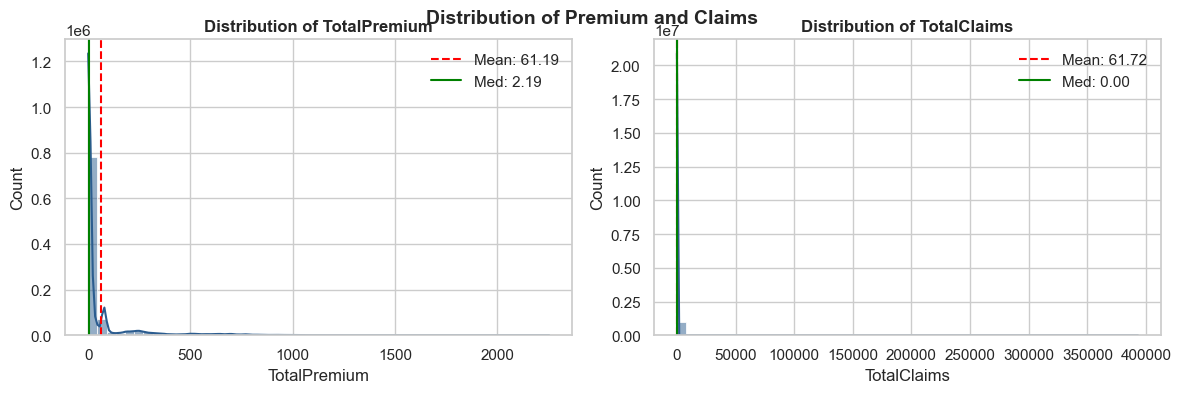


Summary Statistics:
       TotalPremium  TotalClaims
count     988797.00    988797.00
mean          61.19        61.72
std          156.54      2342.00
min            0.00         0.00
25%            0.00         0.00
50%            2.19         0.00
75%           21.93         0.00
max         2253.51    393092.11

 What this tells us:
  • Median Premium: R2.19
  • Median Claim: R0.00
  • % with zero claims: 99.7%


In [11]:
# ============================================
# UNIVARIATE ANALYSIS - NUMERICAL
# ============================================

# Select only the most important numerical columns
key_numerical = ['TotalPremium', 'TotalClaims']

# Plot histograms
EDAUtils.plot_histograms(df, key_numerical, figsize=(12, 4))
plt.suptitle('Distribution of Premium and Claims', fontsize=14, fontweight='bold')
plt.show()

# Quick statistics
print("\nSummary Statistics:")
print(df[key_numerical].describe().round(2))

# Simple interpretation
print("\n What this tells us:")
print(f"  • Median Premium: R{df['TotalPremium'].median():.2f}")
print(f"  • Median Claim: R{df['TotalClaims'].median():.2f}")
print(f"  • % with zero claims: {(df['TotalClaims'] == 0).mean()*100:.1f}%")

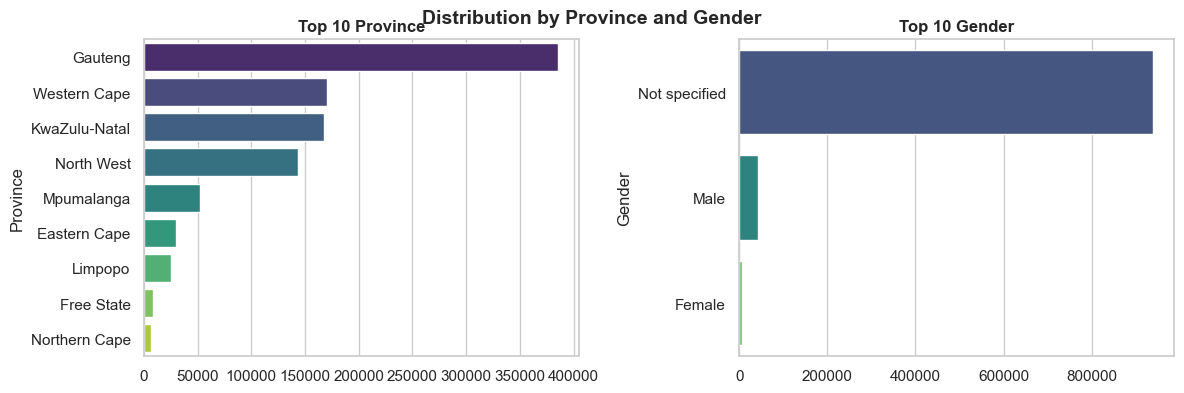


Province:
Province
Gauteng          385395
Western Cape     170079
KwaZulu-Natal    167777
North West       143272
Mpumalanga        52633
Eastern Cape      30329
Limpopo           24835
Free State         8097
Northern Cape      6380
Name: count, dtype: int64

Gender:
Gender
Not specified    939927
Male              42116
Female             6754
Name: count, dtype: int64


In [12]:
# ============================================
# UNIVARIATE ANALYSIS - CATEGORICAL
# ============================================

# Select only the most important categorical columns
key_categorical = ['Province', 'Gender']

# Plot bar charts (only if columns exist)
existing_cat = [col for col in key_categorical if col in df.columns]

if existing_cat:
    EDAUtils.plot_bar_charts(df, existing_cat, figsize=(12, 4))
    plt.suptitle('Distribution by Province and Gender', fontsize=14, fontweight='bold')
    plt.show()
    
    # Print frequencies
    for col in existing_cat:
        print(f"\n{col}:")
        print(df[col].value_counts())

### Bivariate / Multivariate Analysis 

SCATTER PLOT: Premium vs Claims by Top 5 ZipCodes


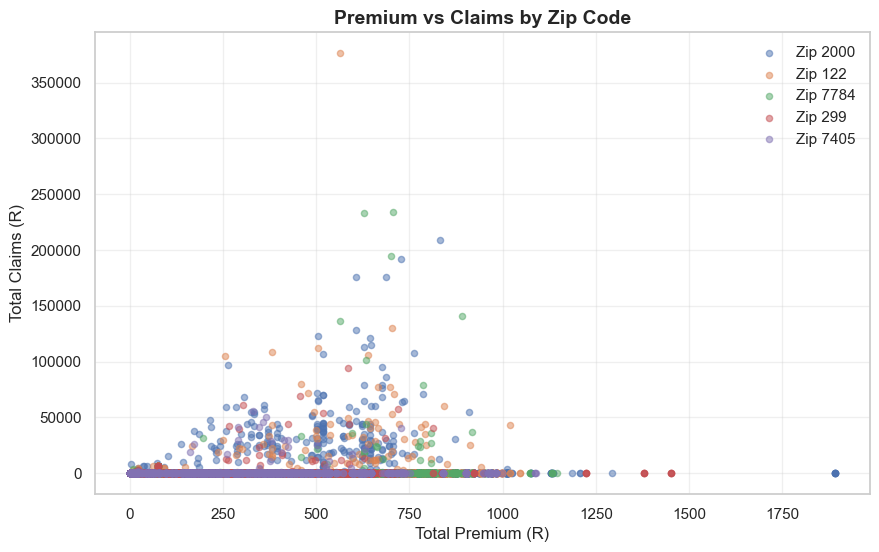

In [13]:

print("=" * 50)
print("SCATTER PLOT: Premium vs Claims by Top 5 ZipCodes")
print("=" * 50)

# Get top 5 zip codes with most policies
top_zipcodes = df['PostalCode'].value_counts().head(5).index.tolist()

# Create scatter plot
plt.figure(figsize=(10, 6))

for zipcode in top_zipcodes:
    subset = df[df['PostalCode'] == zipcode]
    plt.scatter(subset['TotalPremium'], subset['TotalClaims'], 
                label=f'Zip {zipcode}', alpha=0.5, s=20)

plt.xlabel('Total Premium (R)', fontsize=12)
plt.ylabel('Total Claims (R)', fontsize=12)
plt.title('Premium vs Claims by Zip Code', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


CORRELATION MATRIX


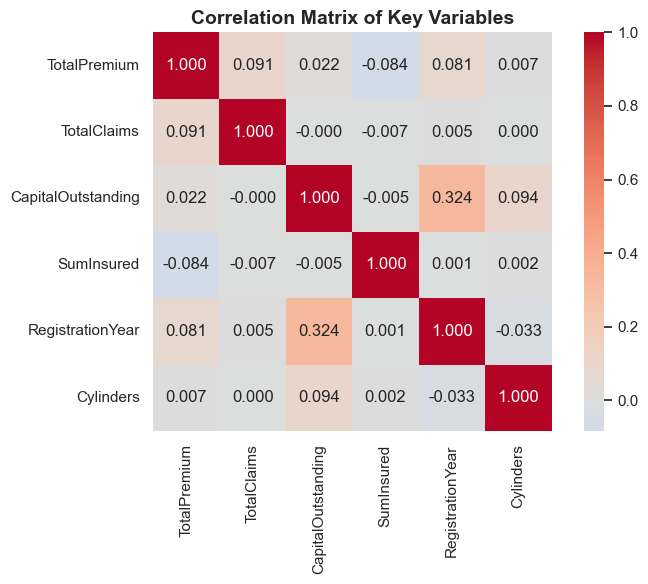

In [14]:
print("=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)

# Select key numerical columns
corr_columns = ['TotalPremium', 'TotalClaims', 'CapitalOutstanding', 
                'SumInsured', 'RegistrationYear', 'Cylinders']

# Only use columns that exist
existing_corr = [col for col in corr_columns if col in df.columns]

# Calculate correlation
corr_matrix = df[existing_corr].corr()


# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True)
plt.title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

GEOGRAPHIC TRENDS BY PROVINCE


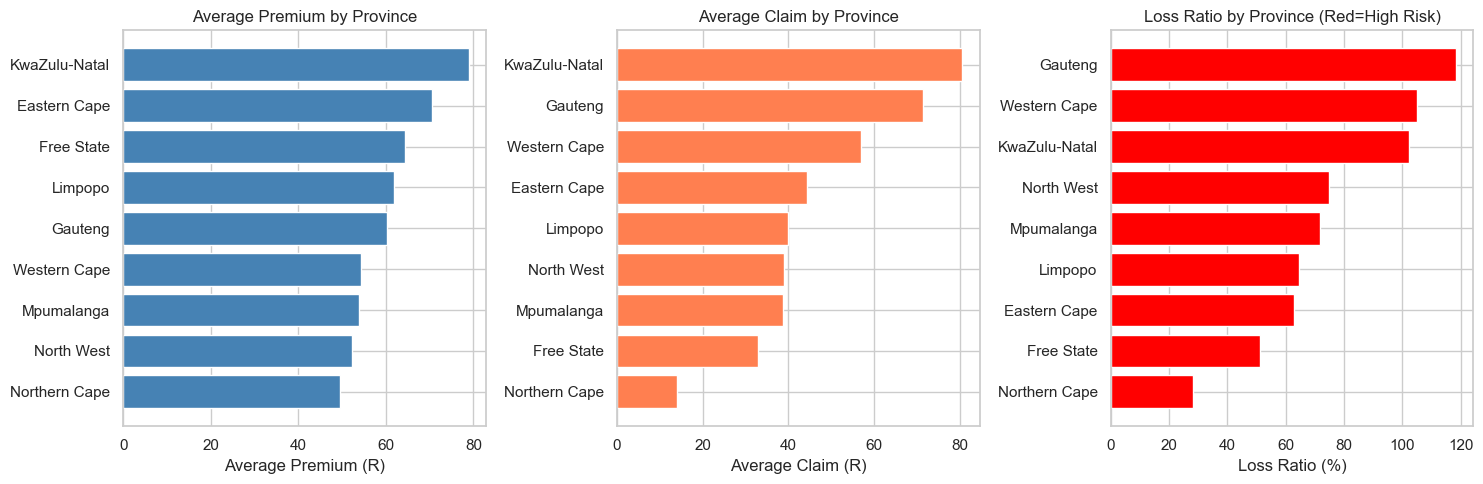

In [15]:
print("=" * 50)
print("GEOGRAPHIC TRENDS BY PROVINCE")
print("=" * 50)

# Group by province
province_metrics = df.groupby('Province').agg({
    'TotalPremium': ['mean', 'sum', 'count'],
    'TotalClaims': ['mean', 'sum']
}).round(2)

# Flatten column names
province_metrics.columns = ['Avg_Premium', 'Total_Premium', 'Policy_Count', 'Avg_Claim', 'Total_Claims']

# Calculate loss ratio
province_metrics['Loss_Ratio'] = (province_metrics['Total_Claims'] / province_metrics['Total_Premium']) * 100
province_metrics = province_metrics.sort_values('Loss_Ratio', ascending=False)
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Average Premium by Province
avg_premium = df.groupby('Province')['TotalPremium'].mean().sort_values()
axes[0].barh(avg_premium.index, avg_premium.values, color='steelblue')
axes[0].set_xlabel('Average Premium (R)')
axes[0].set_title('Average Premium by Province')

# Average Claim by Province
avg_claim = df.groupby('Province')['TotalClaims'].mean().sort_values()
axes[1].barh(avg_claim.index, avg_claim.values, color='coral')
axes[1].set_xlabel('Average Claim (R)')
axes[1].set_title('Average Claim by Province')

# Loss Ratio by Province
loss_ratio = (df.groupby('Province')['TotalClaims'].sum() / df.groupby('Province')['TotalPremium'].sum() * 100).sort_values()
colors = ['red' if x > 10 else 'green' for x in loss_ratio.values]
axes[2].barh(loss_ratio.index, loss_ratio.values, color=colors)
axes[2].set_xlabel('Loss Ratio (%)')
axes[2].set_title('Loss Ratio by Province (Red=High Risk)')

plt.tight_layout()
plt.show()


In [25]:
# 4. Outlier Detection

print("\n OUTLIER DETECTION (IQR Method):")
for col in ['TotalPremium', 'TotalClaims']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = df[df[col] > upper]
    print(f"   {col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)")



 OUTLIER DETECTION (IQR Method):
   TotalPremium: 206,366 outliers (20.87%)
   TotalClaims: 2,613 outliers (0.26%)


LOSS RATIO ANALYSIS

In [20]:
print("=" * 60)
print("LOSS RATIO ANALYSIS")
print("=" * 60)

# Overall and by Province
loss_results = EDAUtils.calculate_loss_ratio(df)

print(f"\n OVERALL LOSS RATIO: {loss_results['overall']['loss_ratio']:.2%}")
print(f"   Total Premium: R{loss_results['overall']['total_premium']:,.2f}")
print(f"   Total Claims: R{loss_results['overall']['total_claims']:,.2f}")

print("\n BY PROVINCE (Highest to Lowest):")
for province, ratio in loss_results['by_province'].items():
    status = "🔴" if ratio > 1 else "🟢"
    print(f"   {status} {province}: {ratio:.2%}")

# By Vehicle Type
if loss_results['by_vehicle'] is not None:
    print("\n BY VEHICLE TYPE:")
    for vehicle, ratio in loss_results['by_vehicle'].head(5).items():
        status = "🔴" if ratio > 1 else "🟢"
        print(f"   {status} {vehicle}: {ratio:.2%}")

# By Gender
gender_loss = EDAUtils.calculate_loss_ratio_by_gender(df)
if gender_loss is not None:
    print("\n📊 BY GENDER:")
    for gender, ratio in gender_loss.items():
        status = "🔴" if ratio > 1 else "🟢"
        print(f"   {status} {gender}: {ratio:.2%}")
    print("   Note: 95% of records have 'Not specified'")

LOSS RATIO ANALYSIS

 OVERALL LOSS RATIO: 100.86%
   Total Premium: R60,503,758.11
   Total Claims: R61,025,857.51

 BY PROVINCE (Highest to Lowest):
   🔴 Gauteng: 118.47%
   🔴 Western Cape: 105.05%
   🔴 KwaZulu-Natal: 102.20%
   🟢 North West: 74.68%
   🟢 Mpumalanga: 71.78%
   🟢 Limpopo: 64.52%
   🟢 Eastern Cape: 62.90%
   🟢 Free State: 51.02%
   🟢 Northern Cape: 28.27%

 BY VEHICLE TYPE:
   🔴 Heavy Commercial: 161.24%
   🔴 Medium Commercial: 102.79%
   🔴 Passenger Vehicle: 100.70%
   🟢 Light Commercial: 23.21%
   🟢 Bus: 0.00%

📊 BY GENDER:
   🔴 Not specified: 101.57%
   🟢 Female: 81.21%
   🟢 Male: 78.40%
   Note: 95% of records have 'Not specified'


In [28]:
print("\n" + "=" * 60)
print("TEMPORAL TRENDS")
print("=" * 60)

trends = EDAUtils.analyze_temporal_trends(df)
print(f"Data period: {trends['monthly_data']['YearMonth'].iloc[0]} to {trends['monthly_data']['YearMonth'].iloc[-1]}")
print(f"First month with claims: {trends['first_month_with_claims']}")
print(f"Trend: {trends['trend']}")
print(f"Change: {trends['change_description']}")


TEMPORAL TRENDS
Data period: 2013-10 to 2015-08
First month with claims: 2013-11
Trend: increasing (claims started after initial period)
Change: Loss ratio increased from 0 to 14.02%


Trend direction: increasing (claims started after initial period)
Change in loss ratio: 14.0%


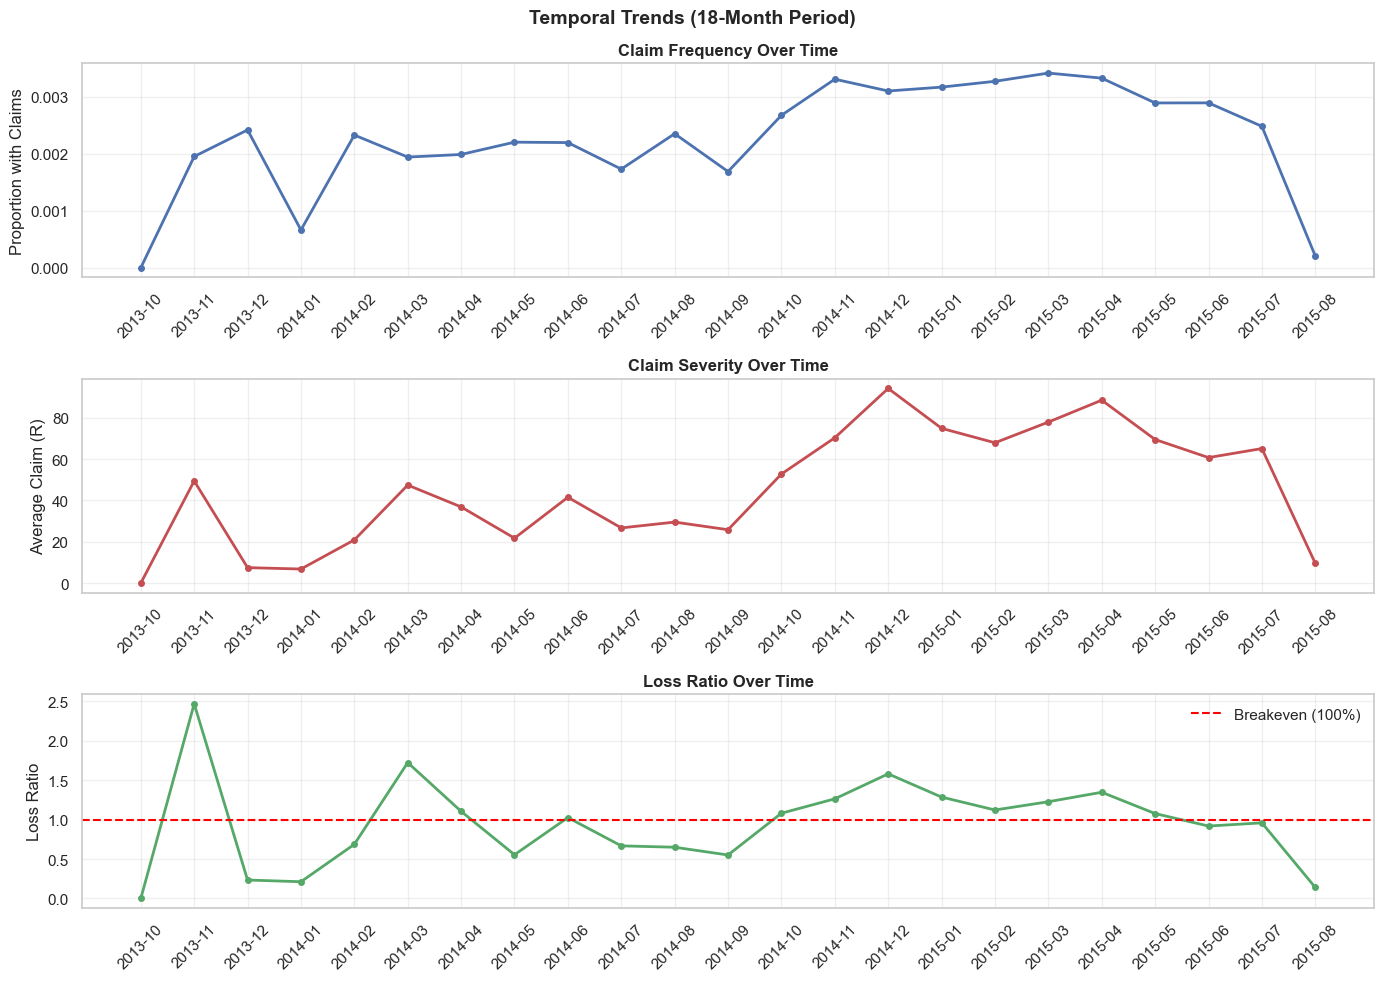

In [29]:
trends = EDAUtils.analyze_temporal_trends(df)
if trends:
    print(f"Trend direction: {trends['trend']}")
    print(f"Change in loss ratio: {trends['change_pct']:.1f}%")
    
    # Plot
    fig = EDAUtils.plot_temporal_trends(df)
    plt.suptitle('Temporal Trends (18-Month Period)', fontsize=14, fontweight='bold')
    plt.show()

In [30]:
# ---------- QUESTION 4: VEHICLE MAKES/MODELS ----------
print("\n" + "=" * 60)
print("QUESTION 4: VEHICLE MAKE/MODEL CLAIMS")
print("=" * 60)

vehicle_results = EDAUtils.analyze_vehicle_claims(df)

if vehicle_results:
    print("\n HIGHEST CLAIM MAKES (Top 5):")
    for make, row in vehicle_results['top_makes'].head(5).iterrows():
        print(f"   {make}: R{row['Total_Claims']:,.2f} claims ({row['Policy_Count']:,.0f} policies)")
    
    print("\n LOWEST CLAIM MAKES (Bottom 5):")
    for make, row in vehicle_results['bottom_makes'].head(5).iterrows():
        print(f"   {make}: R{row['Total_Claims']:,.2f} claims")
    
    print("\n TOP MODELS FOR HIGHEST RISK MAKES:")
    for make, models in vehicle_results['top_models'].items():
        print(f"\n   {make}:")
        for model, row in models.head(3).iterrows():
            print(f"      - {model}: R{row['TotalClaims']:,.2f}")
else:
    print(" Insufficient vehicle make data for analysis")


QUESTION 4: VEHICLE MAKE/MODEL CLAIMS

 HIGHEST CLAIM MAKES (Top 5):
   TOYOTA: R49,410,679.19 claims (509,376 policies)
   MERCEDES-BENZ: R2,896,923.82 claims (24,830 policies)
   VOLKSWAGEN: R1,663,697.20 claims (12,744 policies)
   CMC: R1,224,565.85 claims (11,375 policies)
   AUDI: R1,018,709.62 claims (3,735 policies)

 LOWEST CLAIM MAKES (Bottom 5):
   HINO: R0.00 claims
   JINBEI                             : R0.00 claims
   MARCOPOLO: R0.00 claims
   PROTON: R0.00 claims
   PEUGEOT: R0.00 claims

 TOP MODELS FOR HIGHEST RISK MAKES:

   TOYOTA:
      - QUANTUM 2.7 SESFIKILE 16s: R11,474,589.25
      - QUANTUM 2.7 SESFIKILE 15s: R10,666,712.37
      - QUANTUM 2.7 SESFIKILE 14s: R9,555,408.06

   MERCEDES-BENZ:
      - SPRINTER 515 CDi HI-ROOF F/C P/V: R880,844.13
      - SPRINTER 416 CDI HI-ROOF F/C P/V: R742,043.51
      - SPRINTER 519 CDi F/C P/V: R364,238.21

   VOLKSWAGEN:
      - CRAFTER 50 2.0 TDi HR 80KW F/C P/V: R758,122.89
      - CRAFTER 50 HR 80 F/C P/V: R337,886.58
